In [2]:
import pandas as pd
import seaborn as sb
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pingouin as pg
import os
import scipy.stats as stats
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
from statsmodels.regression.mixed_linear_model import MixedLM
import warnings
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.style.use('/Users/amonast/Documents/GitHub/CA1_Engram_Dynamics/figures/paper_style.mplstyle')
plt.rcParams['figure.figsize'] = (6,4)
palette2={'Tagged vs Non-tagged':'#FFC40C','Non-tagged vs Non-tagged':'#00ABC8','Tagged vs Tagged':'#F37243'}
palette1={'EN':'#FFC40C','NN':'#00ABC8','EE':'#F37243'}

savepath = '/Users/amonast/BOSTON UNIVERSITY Dropbox/Amy Monasterio/Manuscripts/Engram2P/Figures/RevisionFigures/Figure4_Supp5'

def load_pairwise_df_all(bin_size): ### get the pairwise correlations for whole time. 
    '''
    bin_size: dataframes to load based on bin size in frame
    '''
    # path=f'/Volumes/AM_SSD1/Spont2P/Analysis/correlation/pairwise_dataframes_reg_rest/{bin_size}_bin'
    # df_pre = pd.read_csv(os.path.join(path,'pairwise_corr_df_pre_reg.csv'),index_col=0)
    # df_post = pd.read_csv(os.path.join(path, 'pairwise_corr_df_post_reg.csv'),index_col=0)
    
    path=f'/Volumes/AM_SSD1/Spont2P/Analysis/correlation/pairwise_dataframes_rest_equalTime/0_lag/{bin_size}_bin_overlap'
    df_pre = pd.read_csv(os.path.join(path,'pairwise_corr_df_pre.csv'),index_col=0)
    df_post = pd.read_csv(os.path.join(path, 'pairwise_corr_df_post.csv'),index_col=0)

    return df_pre,df_post
def filter_by_pval(df_pre, df_post, p_thresh=0.05):
    """
    Filters rows where p-value is below threshold in both df_pre and df_post.
    """
    mask = (df_pre['pvals'] < p_thresh) & (df_post['pvals'] < p_thresh)
    
    df_pre_filtered = df_pre[mask].copy()
    df_post_filtered = df_post[mask].copy()
    
    return df_pre_filtered, df_post_filtered
def filter_single_df_by_pval(df, p_thresh=0.05):
    """
    Returns rows where p-value is below the given threshold.
    """
    return df[df['pvals'] < p_thresh].copy()

In [3]:
def mean_ani_thresholded(binsize,pvals=[.05,0.01, 0.001, 0.0001, 0.00001]):
    across_pvals = []
    df_long = []
    for pval in pvals:
        df_pre, df_post = load_pairwise_df_all(binsize)
        
        # Add ID to track cells
        df_pre['id'] = np.arange(len(df_pre))
        df_post['id'] = np.arange(len(df_post))

        # Apply cell-wise thresholding
        df1, df2 = filter_by_pval(df_pre, df_post, p_thresh=pval)
        
        # Remove bad values
        df1 = df1[~df1.eq(999).any(axis=1) & (df1['Spearmans R'] > 0)]
        df2 = df2[~df2.eq(999).any(axis=1) & (df2['Spearmans R'] > 0)]

        # Keep only ids that are present in both (optional safeguard)
        common_ids = set(df1['id']).intersection(df2['id'])
        df1 = df1[df1['id'].isin(common_ids)]
        df2 = df2[df2['id'].isin(common_ids)]

        # Merge on cell id to compute per-cell ratio
        df_merged = pd.merge(
            df1[['id', 'Spearmans R', 'Group', 'Animal', 'Pair Group']],
            df2[['id', 'Spearmans R']],
            on='id',
            suffixes=('_pre', '_post')
        )

        df_merged['R_ratio'] = df_merged['Spearmans R_post'] / df_merged['Spearmans R_pre']
        df_merged['thr'] = pval
        df_merged['bin_size'] = binsize * (1 / 30)

        df_long.append(df_merged)

        # Group per-animal AFTER ratio is computed
        df_grouped = df_merged.groupby(['Group', 'Animal', 'Pair Group'])['R_ratio'].mean().reset_index()
        df_grouped['thr'] = pval
        df_grouped['bin_size'] = binsize * (1 / 30)

        across_pvals.append(df_grouped)

    df_thr_long = pd.concat(df_long, ignore_index=True)
    plot_pvals = pd.concat(across_pvals, ignore_index=True)
    plot_pvals['Population']=plot_pvals['Pair Group'].map({'Tagged vs Tagged':'EE','Tagged vs Non-tagged':'EN','Non-tagged vs Non-tagged':'NN'})
    return plot_pvals,df_thr_long

# Fig 4C

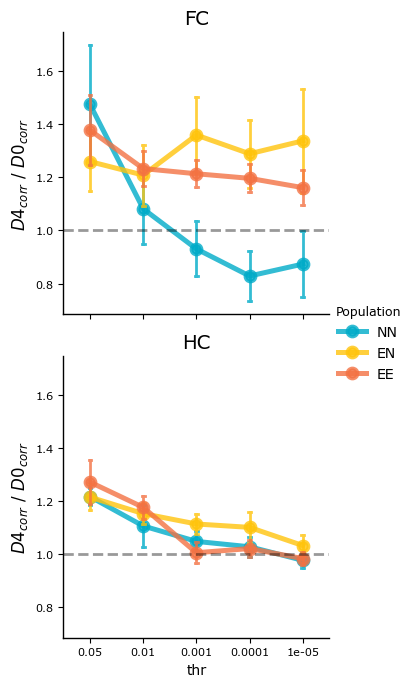

In [18]:
pvals = [.05,0.01, 0.001, 0.0001, 0.00001]
binsize=50
plot_pvals,df_thr_long = mean_ani_thresholded(binsize=binsize,pvals=pvals)
g=sb.catplot(data=plot_pvals,
            hue='Population',
            row='Group',
            x='thr',
            y='R_ratio',
            kind='point',
            capsize=.05,
            alpha=.8,
            order = sorted(plot_pvals['thr'].unique())[::-1],
            palette=palette1,
            markers='o',
            linewidth=1,
            scale=1,
            join=True,
            height=3.5,aspect=1,
            dodge=0,
            legend=True,
            errorbar='se',
            err_kws=dict(lw=2))
g.axes[0,0].set_ylabel('$D4_{corr}\ /\ D0_{corr}$',size=12)
g.axes[0,0].set_title('FC',size=14)
g.axes[1,0].set_ylabel('$D4_{corr}\ /\ D0_{corr}$',size=12)
g.axes[1,0].set_title('HC',size=14)
g.axes[0,0].axhline(1,0,5,color='k',alpha=.4,linestyle='dashed')
g.axes[1,0].axhline(1,0,5,color='k',alpha=.4,linestyle='dashed')
# for ax in g.axes[:, 0]:
#     ax.tick_params(axis='x', labelsize=9)
# for ax in g.axes[:, 0]:
#     ax.tick_params(axis='y', labelsize=12)

# g.axes[1,0].set_xlabel('p-value threshold', size=12)  # change 12 to any desired font size

plt.savefig(f'{savepath}/point_across_pvals_rest_bin{binsize}.svg',transparent=True)

In [7]:
plot_pvals=plot_pvals.dropna()
plot_pvals['Pair_Group']=plot_pvals['Population']
plot_pvals['Group'] = pd.Categorical(plot_pvals['Group'], categories=["HC", "FC"], ordered=True)
plot_pvals['Population'] = pd.Categorical(plot_pvals['Population'], categories=["NN", "EN", "EE"], ordered=True)

model = smf.mixedlm("R_ratio ~ Group * Population * thr ", 
                     plot_pvals, groups=plot_pvals["Animal"])
results=model.fit()
results.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                    Mixed Linear Model Regression Results
=============================================================================
Model:                    MixedLM         Dependent Variable:         R_ratio
No. Observations:         189             Method:                     REML   
No. Groups:               13              Scale:                      0.0549 
Min. group size:          12              Log-Likelihood:             4.1607 
Max. group size:          15              Converged:                  Yes    
Mean group size:          14.5                                               
-----------------------------------------------------------------------------
                                  Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                          1.028    0.061 16.995 0.000   0.910  1.147
Group[T.FC]                       -0.137    0.081 -1.687 0.092  -0.295  0.022
Population[T.EN]                   0.065    0.074  0.871 0.384  -0.081  0.211
Population[T.EE]                  -0.001    0.074 -0.014 0.989  -0.145  0.143
Group[T.FC]:Population[T.EN]       0.349    0.100  3.483 0.000   0.152  0.545
Group[T.FC]:Population[T.EE]       0.303    0.100  3.025 0.002   0.107  0.499
thr                                3.918    2.256  1.737 0.082  -0.503  8.339
Group[T.FC]:thr                    7.999    3.052  2.621 0.009   2.017 13.982
Population[T.EN]:thr              -1.349    3.175 -0.425 0.671  -7.572  4.874
Population[T.EE]:thr               1.330    3.166  0.420 0.674  -4.874  7.535
Group[T.FC]:Population[T.EN]:thr -11.818    4.312 -2.741 0.006 -20.269 -3.367
Group[T.FC]:Population[T.EE]:thr  -9.571    4.312 -2.220 0.026 -18.022 -1.120
Group Var                          0.005    0.016                            
=============================================================================

"""

# Fig 4D

In [27]:
pvals = [0.05, 0.01, 0.001, 0.0001, 0.00001]
bin_sizes = [4,8,16,25,50,80,100,125]
df_ratios = []

for binsize in bin_sizes:
    for pval in pvals:
        df_pre, df_post = load_pairwise_df_all(binsize)
        
        # Add ID to track cells
        df_pre['id'] = np.arange(len(df_pre))
        df_post['id'] = np.arange(len(df_post))

        # Apply cell-wise thresholding
        df1, df2 = filter_by_pval(df_pre, df_post, p_thresh=pval)
        
        # Remove bad values
        df1 = df1[~df1.eq(999).any(axis=1) & (df1['Spearmans R'] > 0)]
        df2 = df2[~df2.eq(999).any(axis=1) & (df2['Spearmans R'] > 0)]

        # Keep only ids that are present in both (optional safeguard)
        common_ids = set(df1['id']).intersection(df2['id'])
        df1 = df1[df1['id'].isin(common_ids)]
        df2 = df2[df2['id'].isin(common_ids)]

        # Merge on cell id to compute per-cell ratio
        df_merged = pd.merge(
            df1[['id', 'Spearmans R', 'Group', 'Animal', 'Pair Group']],
            df2[['id', 'Spearmans R']],
            on='id',
            suffixes=('_pre', '_post')
        )

        df_merged['R_ratio'] = df_merged['Spearmans R_post'] / df_merged['Spearmans R_pre']
        df_merged['thr'] = pval
        df_merged['bin_size'] = binsize * (1 / 30)


        # Group per-animal AFTER ratio is computed
        df_grouped = df_merged.groupby(['Group', 'Animal', 'Pair Group'])['R_ratio'].mean().reset_index()
        df_grouped['thr'] = pval
        df_grouped['bin_size'] = binsize * (1 / 30)

        df_ratios.append(df_grouped)

# Final long dataframe
df_ratio_long = pd.concat(df_ratios, ignore_index=True)
df_ratio_long['Population']=df_ratio_long['Pair Group'].map({'Tagged vs Tagged':'EE','Tagged vs Non-tagged':'EN','Non-tagged vs Non-tagged':'NN'})


In [28]:
df_ratio_long=df_ratio_long.dropna()
df_ratio_long['Group'] = pd.Categorical(df_ratio_long['Group'], categories=["HC", "FC"], ordered=True)
df_ratio_long['Population'] = pd.Categorical(df_ratio_long['Population'], categories=["NN", "EN", "EE"], ordered=True)

model = smf.mixedlm("R_ratio ~ Group * Population + bin_size + thr ", 
                     df_ratio_long, groups=df_ratio_long["Animal"])
results=model.fit()
print(results.summary())
print(results.pvalues)

                 Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      R_ratio  
No. Observations:        1493         Method:                  REML     
No. Groups:              13           Scale:                   0.0767   
Min. group size:         96           Log-Likelihood:          -236.8928
Max. group size:         120          Converged:               Yes      
Mean group size:         114.8                                          
------------------------------------------------------------------------
                             Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                     1.234    0.049  25.299 0.000  1.138  1.329
Group[T.FC]                   0.037    0.065   0.569 0.569 -0.091  0.165
Population[T.EN]              0.038    0.026   1.492 0.136 -0.012  0.089
Population[T.EE]             -0.019    0.026  -0.734 0.463 -0.069  0.

In [29]:
def plot_r_ratio_heatmap_by_population(df, group, vmin=.8, vmax=1.6, center=1.0,cmap='magma',figsize=(7,2),gridspec_kw=None):
    """
    Plots a grid of heatmaps — one for each Pair Group — showing mean R_ratio
    across threshold and bin size levels for a given experimental group (e.g., FC or HC).
    """

    df_group = df[df['Group'] == group].copy()
    df_group['Population'] = df_group['Pair Group'].map({'Tagged vs Tagged':'E/E',
                                                               'Tagged vs Non-tagged':'E/N',
                                                               'Non-tagged vs Non-tagged':'N/N'})
    pair_groups = np.sort(df_group['Population'].unique())
    n_cols = 3
    n_rows = int(np.ceil(len(pair_groups) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols+1, figsize=figsize, squeeze=False,gridspec_kw=gridspec_kw)
    cbar_ax = axes[0, 3]  # the reserved colorbar axis

    for i, pair in enumerate(pair_groups):
        ax = axes[i // n_cols, i % n_cols]

        # Subset and aggregate
        df_subset = df_group[df_group['Population'] == pair]
        df_mean = (
            df_subset.groupby(['thr', 'bin_size'])['R_ratio']
            .mean()
            .reset_index()
        )
        
        heatmap_data = df_mean.pivot(index='thr', columns='bin_size', values='R_ratio')
        heatmap_data = heatmap_data.sort_index(ascending=False)
        heatmap_data.columns = heatmap_data.columns.to_numpy().round(2)

        sb.heatmap(
            heatmap_data,
            ax=ax,
            annot=False,
            fmt=".2f",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            cbar=(i == len(pair_groups) - 1),  # Only show colorbar on the last heatmap
            cbar_ax=cbar_ax,
            center=center,
            cbar_kws={'label':r'$D4_{corr}\ /\ D0_{corr}$','shrink':.2,'aspect':.5} if i == len(pair_groups) - 1 else None
        )
        ax.set_title(f'{pair}')
        ax.set_xlabel('Bin Size (s)')
        #ax.set_yticklabels([f'{float(label.get_text()):1e}' for label in ax.get_yticklabels()])
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


        if i==0:
            ax.set_ylabel('P-Value Threshold',ha='center') 
        else: 
            ax.set_ylabel('') 
            
        #ax.set_aspect('equal')

    # Remove empty subplots if any
    for j in range(i + 1, n_rows * n_cols):
        fig.delaxes(axes[j // n_cols, j % n_cols])
        
    plt.rcParams.update({
    'font.size': 12,            # Base font size
    'axes.titlesize': 10,       # Title size
    'axes.labelsize': 10,       # X/Y axis labels
    'xtick.labelsize': 8,      # X-tick labels
    'ytick.labelsize': 8,      # Y-tick labels
    'legend.fontsize': 10,      # Legend text
    'figure.titlesize': 10      # Suptitle (if any)
})


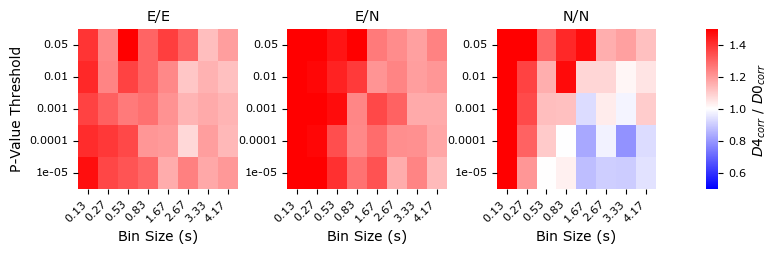

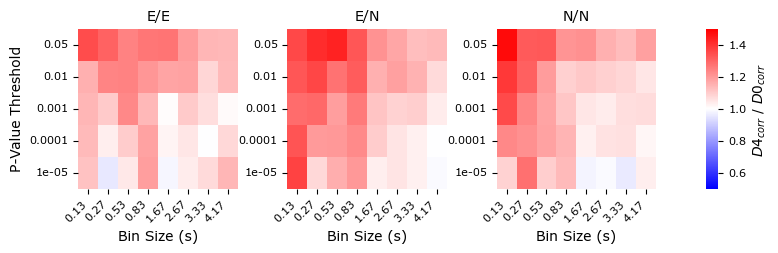

In [30]:
plot_r_ratio_heatmap_by_population(df_ratio_long, vmin=.5,vmax=1.5,group='FC',figsize=(8,2),gridspec_kw={'width_ratios':[1,1,1,.08]},cmap='bwr')
plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.4,hspace=1)
plt.savefig(f'Fig4D_heatmap_Rratio_FC_rest.svg',transparent=True)
plot_r_ratio_heatmap_by_population(df_ratio_long, vmin=.5,vmax=1.5,group='HC',figsize=(8,2),gridspec_kw={'width_ratios':[1,1,1,.08]},cmap='bwr')
plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.4,hspace=1)
plt.savefig('Fig4D_heatmap_Rratio_HC_rest.svg',transparent=True)